In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/Walmart DataSet.csv')
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [4]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


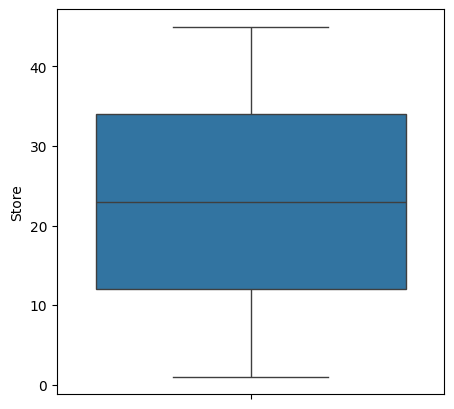

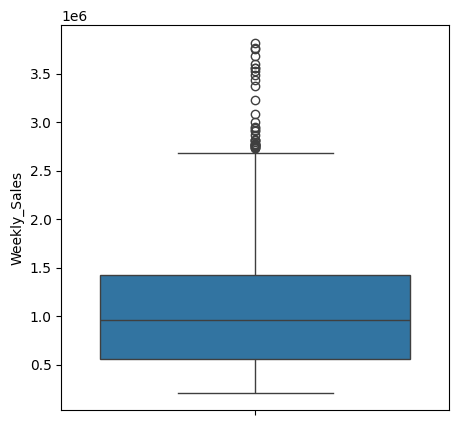

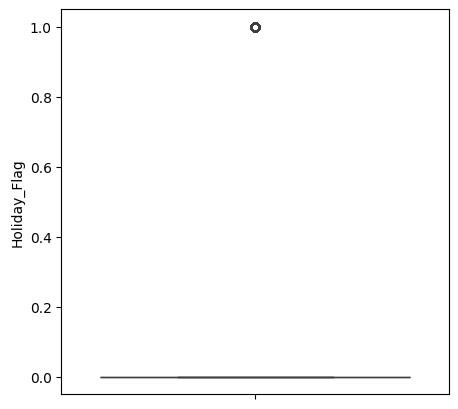

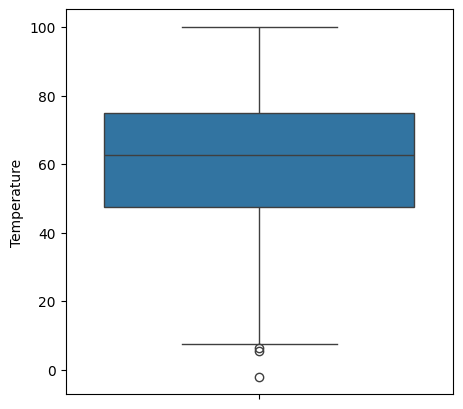

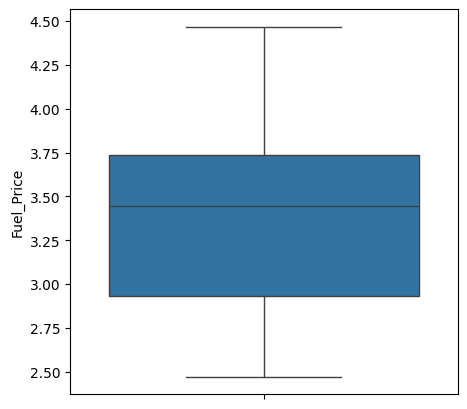

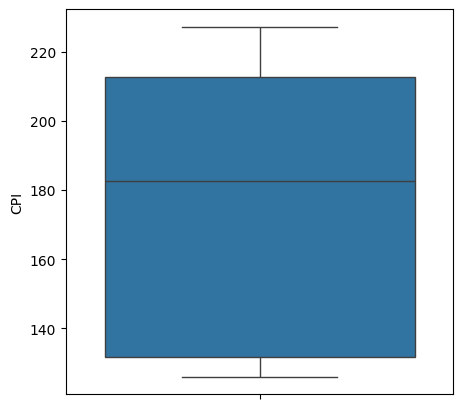

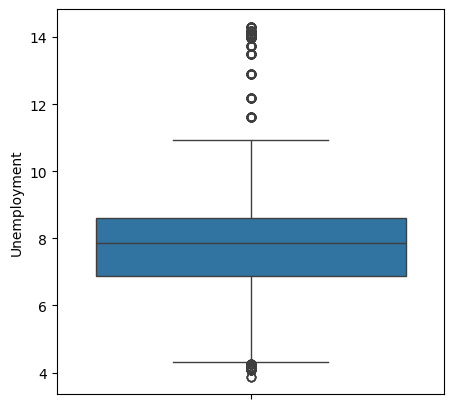

In [7]:
for col in df.columns:
  if df[col].dtype != 'object':
    plt.figure(figsize=(5,5))
    sns.boxplot(df[col])
    plt.show()

# From above BoxPlots, Outliers are present in columns such as Unemployment column, temperature Column and weekly_Sales Column

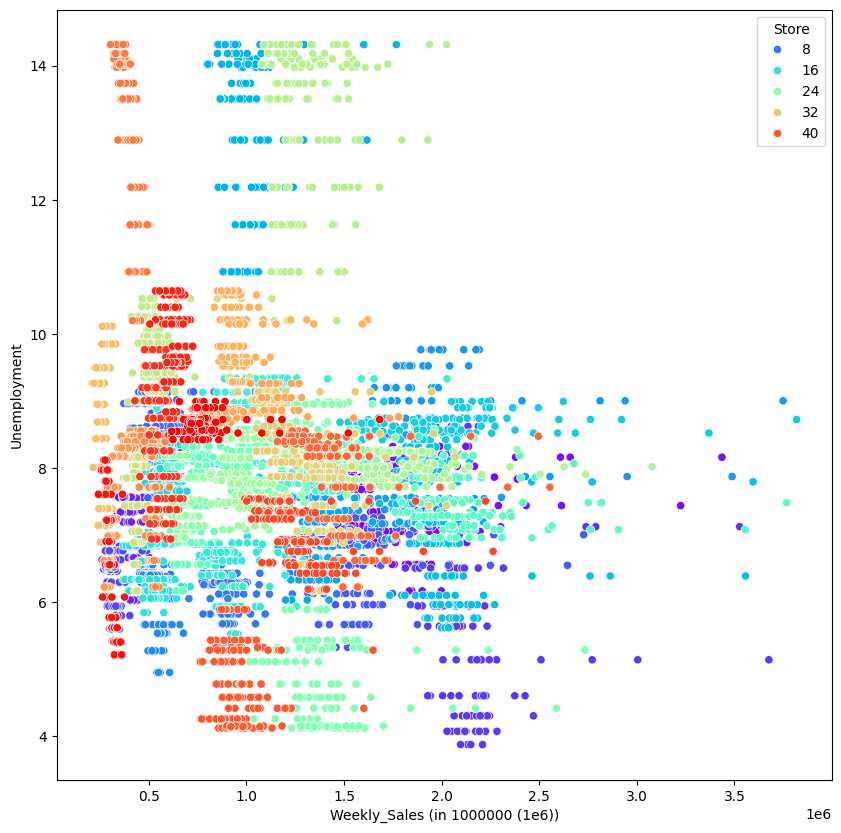

In [8]:
# checking if unemployment rate affecting weekly Sales for Each Store
plt.figure(figsize=(10,10))
sns.scatterplot(x=df['Weekly_Sales'], y = df['Unemployment'], hue = df['Store'], palette = 'rainbow')
plt.xlabel('Weekly_Sales (in 1000000 (1e6))')
plt.ylabel('Unemployment')
plt.show()

**Although Correlation between Unemployment and weekly Sales are less but as we can see from above scatterplot Store Numbers from 32 to 45 suffering most**

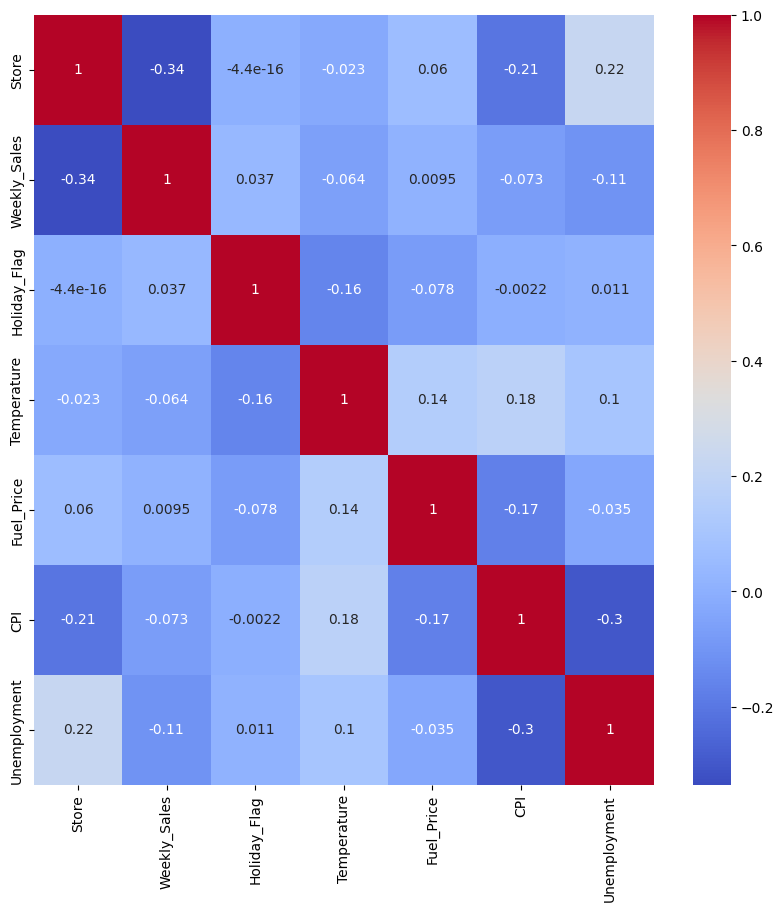

In [9]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


No temperature column does not affect weekly_sales in any manner, because the correlation between temperature column and weekly_Sales column is very weak - 0.064

From above correlation Heatmap, consumer price index (CPI) column does not affect Weekly_Sales, because the correlation between them is also very weak - 0.073

# Checking for Significant Difference between Best Perforrming and Worst performing STores and which STores are Best Performing and Worst Performing

In [10]:
# Top Performing Stores by Weekly_Sales
df_group = df.groupby('Store')['Weekly_Sales'].sum()
df_group.sort_values(ascending=False).head(10)

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08
10,2.716177e+08
27,2.538559e+08
6,2.237561e+08
1,2.224028e+08


Frome above analysis, Top 10 Performing Stores by Weekly_Sales are 1, 2, 4, 6, 10, 13, 14, 20, 27 and 39

In [11]:
# Worst Performing Stores by Weekly Sales
df_group_2 = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).tail(10)
df_group_2

,Weekly_Sales
Store,
29,77141554.31
16,74252425.40
37,74202740.32
30,62716885.12
3,57586735.07
38,55159626.42
36,53412214.97
5,45475688.90
44,43293087.84


Frome above code, worst performing stores are 3, 5, 16, 29, 30, 33, 36, 37, 38, 44 - 33 is the very worst performing store

 Now, for checking how significant difference between top performing and worst performing stores by weekly_sales

In [12]:
from scipy.stats import ttest_ind
# null hypothesis - There is no significant difference between top performing and worst performing stored
# Alternate - There is significance Difference between Top performing and Worst performing stores
t_statistic, p_value = ttest_ind(df_group, df_group_2)
print(f'T-statistic: {t_statistic}')
print(f'P-value: {p_value}')
if p_value < 0.05:
  print('Reject null hypothesis')
else:
  print('Fail to reject null hypothesis')

T-statistic: 3.669901761596689
P-value: 0.0005642635331716097
Reject null hypothesis


since there p << 0.05 then rejecting null hypothesis and we have significant difference between top performing and worst performing stores

In [13]:
from statistics import mean
print(f'Mean of top performing stores: {mean(df_group)}')
print(f'Mean of worst performing stores: {mean(df_group_2)}')
print(f'Difference in means: {mean(df_group) - mean(df_group_2)}')
# The significance level = 91675859.46 which shows highly significance between top and worst performing stores

Mean of top performing stores: 149715977.49133334
Mean of worst performing stores: 58040118.031
Difference in means: 91675859.46033333


Now we are going to perform time series forecasting

In [14]:
#first we have to convert date column to data-time data type
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.dtypes

,0
Store,int64
Date,datetime64[ns]
Weekly_Sales,float64
Holiday_Flag,int64
Temperature,float64
Fuel_Price,float64
CPI,float64
Unemployment,float64


In [15]:
df.set_index('Date', inplace=True)
df

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106
2010-02-12,1,1641957.44,1,38.51,2.548,211.242170,8.106
2010-02-19,1,1611968.17,0,39.93,2.514,211.289143,8.106
2010-02-26,1,1409727.59,0,46.63,2.561,211.319643,8.106
2010-03-05,1,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...
2012-09-28,45,713173.95,0,64.88,3.997,192.013558,8.684
2012-10-05,45,733455.07,0,64.89,3.985,192.170412,8.667
2012-10-12,45,734464.36,0,54.47,4.000,192.327265,8.667


In [16]:
# we have to forecast weekly sales for each store so we need to drop other columns except store and weekly_sales columns
df.drop(['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag'], axis=1, inplace=True)
df

,Store,Weekly_Sales
Date,,
2010-02-05,1,1643690.90
2010-02-12,1,1641957.44
2010-02-19,1,1611968.17
2010-02-26,1,1409727.59
2010-03-05,1,1554806.68
...,...,...
2012-09-28,45,713173.95
2012-10-05,45,733455.07
2012-10-12,45,734464.36


In [17]:
df_1 = df[df['Store'] == 1]['Weekly_Sales']
df_2 = df[df['Store'] == 2]['Weekly_Sales']
df_3 = df[df['Store'] == 3]['Weekly_Sales']
df_4 = df[df['Store'] == 4]['Weekly_Sales']
df_5 = df[df['Store'] == 5]['Weekly_Sales']
df_1

,Weekly_Sales
Date,
2010-02-05,1643690.90
2010-02-12,1641957.44
2010-02-19,1611968.17
2010-02-26,1409727.59
2010-03-05,1554806.68
...,...
2012-09-28,1437059.26
2012-10-05,1670785.97
2012-10-12,1573072.81


# Plots Data set filtered by STore number for checking insights

<Axes: xlabel='Date'>

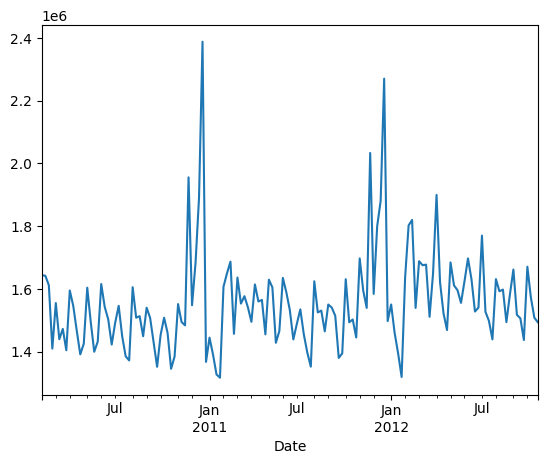

In [18]:
# now we plot the dataset to check for insights
df_1.plot()

<Axes: xlabel='Date'>

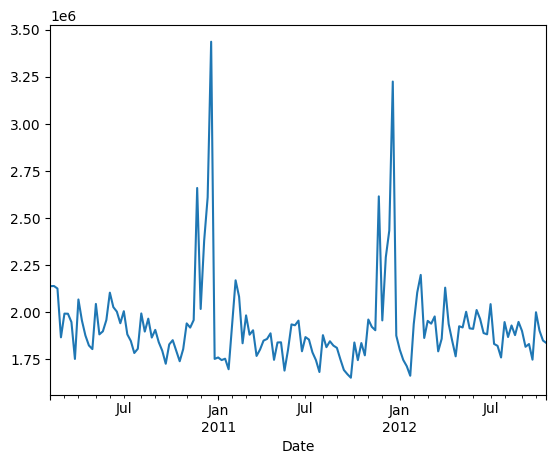

In [19]:
# now we plot the dataset to check for insights
df_2.plot()

<Axes: xlabel='Date'>

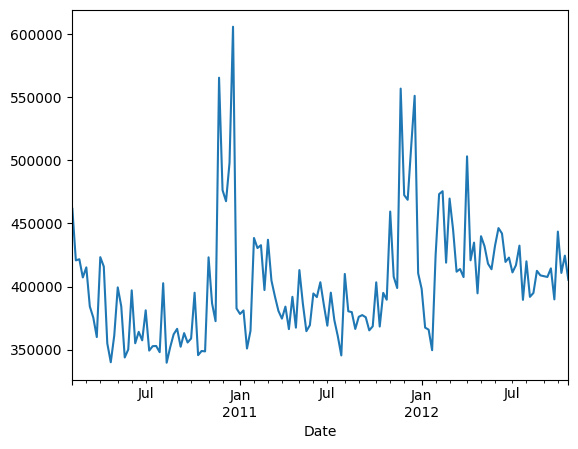

In [20]:
# now we plot the dataset to check for insights
df_3.plot()

<Axes: xlabel='Date'>

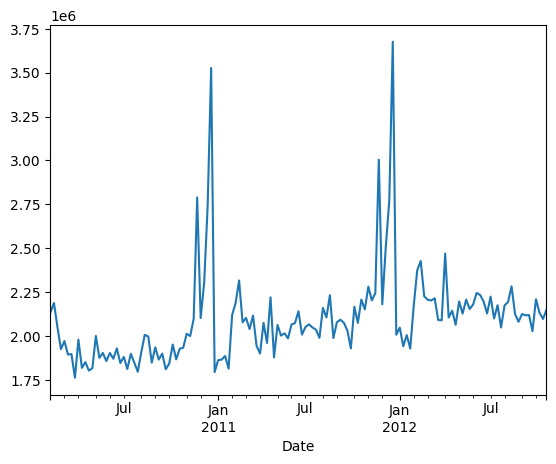

In [21]:
# now we plot the dataset to check for insights
df_4.plot()

<Axes: xlabel='Date'>

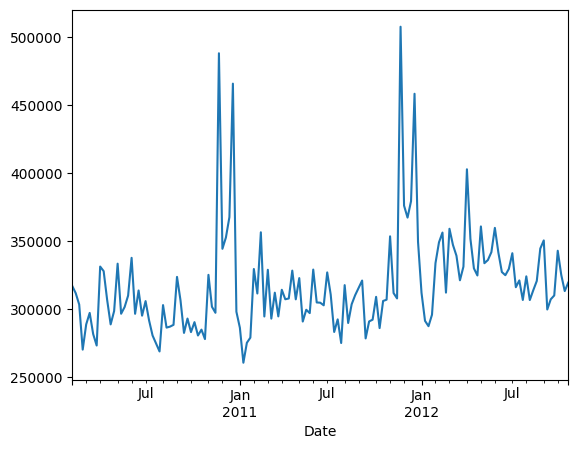

In [22]:
# now we plot the dataset to check for insights
df_5.plot()

# From Above plots we can see seasonal trend near january 2011 and january 2012, in all 5 stores and that may be because of holidays

# Performing Augmented Dickey-Fuller Test for checking of Stationarity

In [23]:
# Stationarity Analysis
#In this part of the demonstration, we will perform tests on the time series data to understand whether it is stationary or not. The autoregressive modeling requires the time series data to be stationary. To test this, we will use the following test:
#Augmented Dickey–Fuller (ADF) test
from statsmodels.tsa.stattools import adfuller
result1 = adfuller(df_1);
result2 = adfuller(df_2);
result3 = adfuller(df_3);
result4 = adfuller(df_4);
result5 = adfuller(df_5);
print('ADF Statistic: %f' % result1[0])
print('p-value: %f' % result1[1])
print(" ")
print('ADF Statistic: %f' % result2[0])
print('p-value: %f' % result2[1])
print(" ")
print('ADF Statistic: %f' % result3[0])
print('p-value: %f' % result3[1])
print(" ")
print('ADF Statistic: %f' % result4[0])
print('p-value: %f' % result4[1])
print(" ")
print('ADF Statistic: %f' % result5[0])
print('p-value: %f' % result5[1])

ADF Statistic: -5.102186
p-value: 0.000014
 
ADF Statistic: -3.708863
p-value: 0.003990
 
ADF Statistic: -2.963868
p-value: 0.038409
 
ADF Statistic: -2.879382
p-value: 0.047799
 
ADF Statistic: -4.310974
p-value: 0.000425


from above adfuller test we have p-value < 0.05 which means reject null hypothesis and therefore our data is stationary
Here Null hypothesis == timeSeries is not stationary
alternate Hypothesis == timeseries is stationary

In [24]:
df_train_1 = pd.DataFrame(df_1[:105])
df_test_1 = pd.DataFrame(df_1[105:])

df_train_2 = pd.DataFrame(df_2[:105])
df_test_2 = pd.DataFrame(df_2[105:])

df_train_3 = pd.DataFrame(df_3[:105])
df_test_3 = pd.DataFrame(df_3[105:])

df_train_4 = pd.DataFrame(df_4[:105])
df_test_4 = pd.DataFrame(df_4[105:])

df_train_5 = pd.DataFrame(df_5[:105])
df_test_5 = pd.DataFrame(df_5[105:])

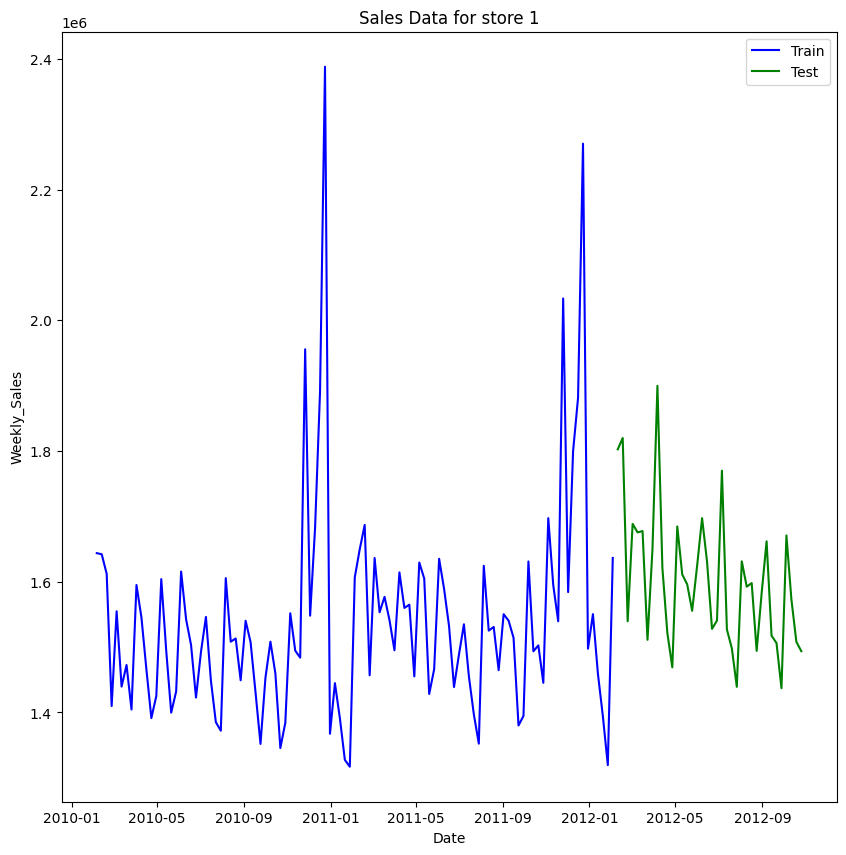

In [25]:
# plot time series according to train-test split
plt.figure(figsize=(10,10))
sns.lineplot(data = df_train_1, x = 'Date', y = 'Weekly_Sales', markers = 'o', color = 'blue', label='Train')
sns.lineplot(data = df_test_1, x = 'Date', y = 'Weekly_Sales', markers = 'o', color = 'green', label='Test')
plt.title('Sales Data for store 1')
plt.show()

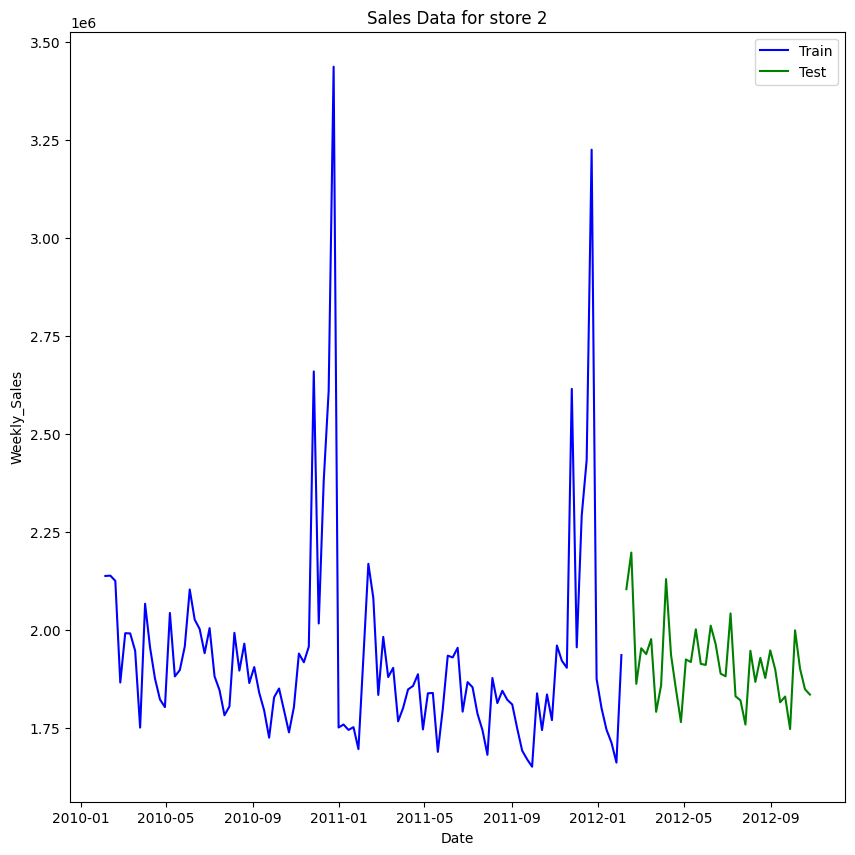

In [26]:
# plot time series according to train-test split
plt.figure(figsize=(10,10))
sns.lineplot(data = df_train_2, x = 'Date', y = 'Weekly_Sales', markers = 'o', color = 'blue', label='Train')
sns.lineplot(data = df_test_2, x = 'Date', y = 'Weekly_Sales', markers = 'o', color = 'green', label='Test')
plt.title('Sales Data for store 2')
plt.show()

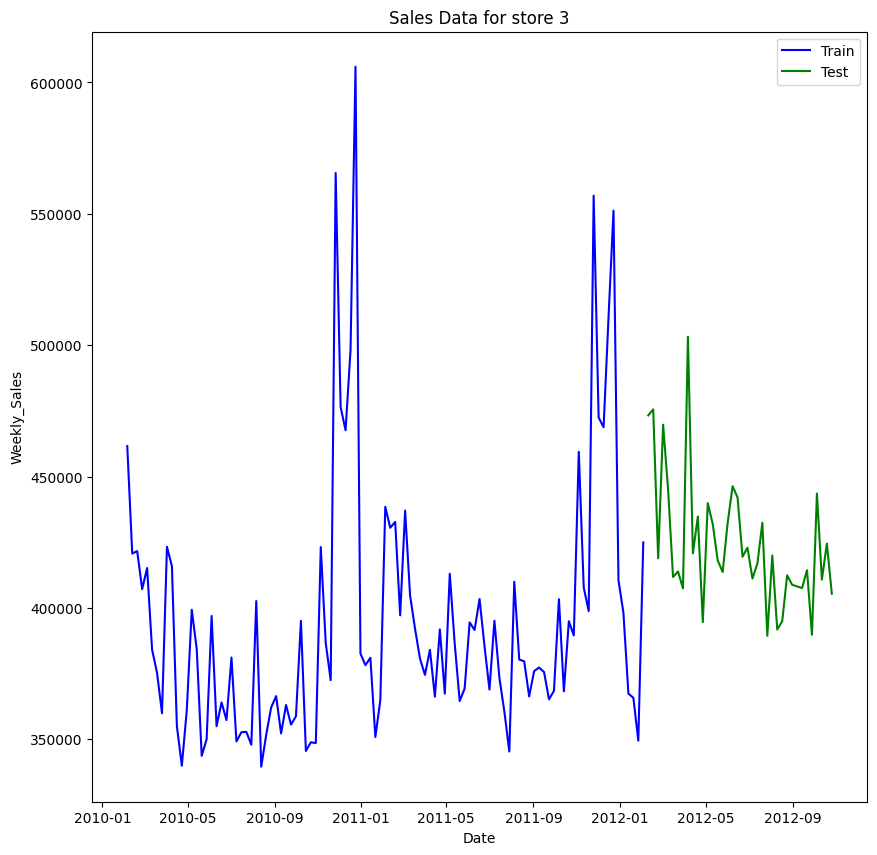

In [27]:
# plot time series according to train-test split
plt.figure(figsize=(10,10))
sns.lineplot(data = df_train_3, x = 'Date', y = 'Weekly_Sales', markers = 'o', color = 'blue', label='Train')
sns.lineplot(data = df_test_3, x = 'Date', y = 'Weekly_Sales', markers = 'o', color = 'green', label='Test')
plt.title('Sales Data for store 3')
plt.show()

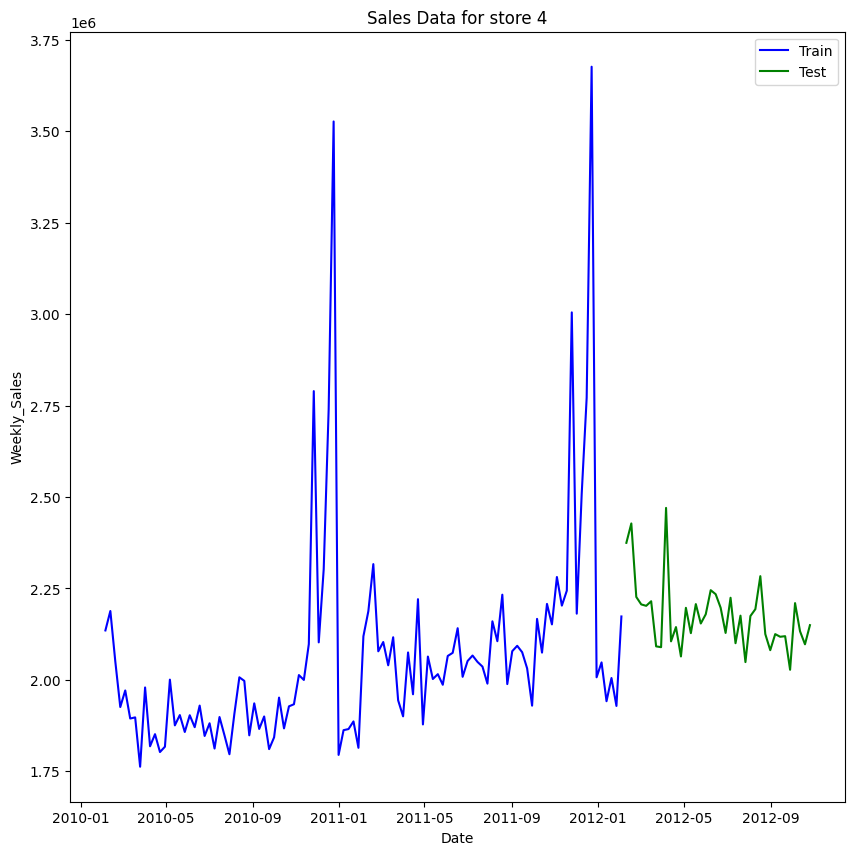

In [28]:
# plot time series according to train-test split
plt.figure(figsize=(10,10))
sns.lineplot(data = df_train_4, x = 'Date', y = 'Weekly_Sales', markers = 'o', color = 'blue', label='Train')
sns.lineplot(data = df_test_4, x = 'Date', y = 'Weekly_Sales', markers = 'o', color = 'green', label='Test')
plt.title('Sales Data for store 4')
plt.show()

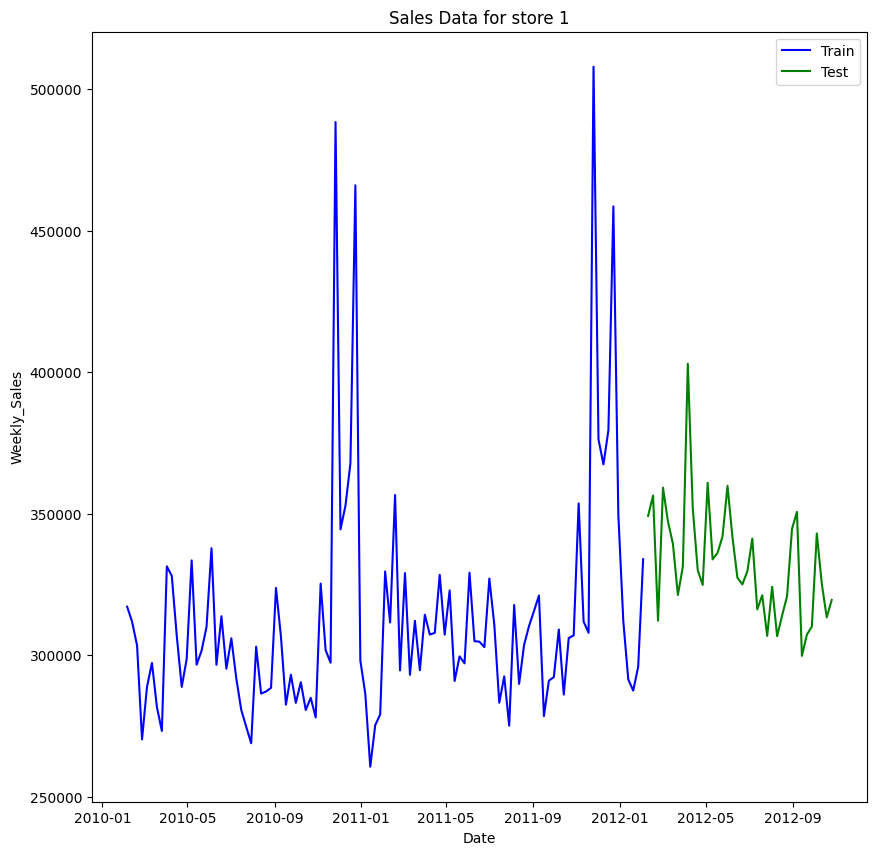

In [29]:
# plot time series according to train-test split
plt.figure(figsize=(10,10))
sns.lineplot(data = df_train_5, x = 'Date', y = 'Weekly_Sales', markers = 'o', color = 'blue', label='Train')
sns.lineplot(data = df_test_5, x = 'Date', y = 'Weekly_Sales', markers = 'o', color = 'green', label='Test')
plt.title('Sales Data for store 1')
plt.show()

In [30]:
# from Above the mean is stationary so we have to make variance constant, we use boxcox transformation method only on training data
df_train_1

,Weekly_Sales
Date,
2010-02-05,1643690.90
2010-02-12,1641957.44
2010-02-19,1611968.17
2010-02-26,1409727.59
2010-03-05,1554806.68
...,...
2012-01-06,1550369.92
2012-01-13,1459601.17
2012-01-20,1394393.84


In [31]:
df_test_1.shape

(38, 1)

In [32]:
df_train_2

,Weekly_Sales
Date,
2010-02-05,2136989.46
2010-02-12,2137809.50
2010-02-19,2124451.54
2010-02-26,1865097.27
2010-03-05,1991013.13
...,...
2012-01-06,1799520.14
2012-01-13,1744725.48
2012-01-20,1711769.11


In [33]:
df_test_2.shape

(38, 1)

In [34]:
df_train_3

,Weekly_Sales
Date,
2010-02-05,461622.22
2010-02-12,420728.96
2010-02-19,421642.19
2010-02-26,407204.86
2010-03-05,415202.04
...,...
2012-01-06,398178.21
2012-01-13,367438.62
2012-01-20,365818.61


In [35]:
df_test_3.shape

(38, 1)

In [36]:
df_train_4

,Weekly_Sales
Date,
2010-02-05,2135143.87
2010-02-12,2188307.39
2010-02-19,2049860.26
2010-02-26,1925728.84
2010-03-05,1971057.44
...,...
2012-01-06,2047766.07
2012-01-13,1941676.61
2012-01-20,2005097.76


In [37]:
df_test_4.shape

(38, 1)

In [38]:
df_train_5

,Weekly_Sales
Date,
2010-02-05,317173.10
2010-02-12,311825.70
2010-02-19,303447.57
2010-02-26,270281.63
2010-03-05,288855.71
...,...
2012-01-06,312078.71
2012-01-13,291454.52
2012-01-20,287523.98


In [39]:
df_test_5.shape

(38, 1)

In [40]:
from scipy.stats import boxcox
df_boxcox_1 = pd.Series(boxcox(df_train_1['Weekly_Sales'], lmbda = 0), index = df_train_1.index)
df_boxcox_1 = pd.DataFrame(df_boxcox_1)
df_boxcox_1.columns = ['Weekly_Sales']
df_boxcox_1

,Weekly_Sales
Date,
2010-02-05,14.312455
2010-02-12,14.311400
2010-02-19,14.292966
2010-02-26,14.158907
2010-03-05,14.256862
...,...
2012-01-06,14.254004
2012-01-13,14.193674
2012-01-20,14.147970


In [41]:
from scipy.stats import boxcox
df_boxcox_2 = pd.Series(boxcox(df_train_2['Weekly_Sales'], lmbda = 0), index = df_train_2.index)
df_boxcox_2 = pd.DataFrame(df_boxcox_2)
df_boxcox_2.columns = ['Weekly_Sales']
df_boxcox_2

,Weekly_Sales
Date,
2010-02-05,14.574909
2010-02-12,14.575292
2010-02-19,14.569024
2010-02-26,14.438824
2010-03-05,14.504154
...,...
2012-01-06,14.403031
2012-01-13,14.372108
2012-01-20,14.353038


In [42]:
from scipy.stats import boxcox
df_boxcox_3 = pd.Series(boxcox(df_train_3['Weekly_Sales'], lmbda = 0), index = df_train_3.index)
df_boxcox_3 = pd.DataFrame(df_boxcox_3)
df_boxcox_3.columns = ['Weekly_Sales']
df_boxcox_3

,Weekly_Sales
Date,
2010-02-05,13.042502
2010-02-12,12.949744
2010-02-19,12.951912
2010-02-26,12.917072
2010-03-05,12.936521
...,...
2012-01-06,12.894655
2012-01-13,12.814312
2012-01-20,12.809893


In [43]:
from scipy.stats import boxcox
df_boxcox_4 = pd.Series(boxcox(df_train_4['Weekly_Sales'], lmbda = 0), index = df_train_4.index)
df_boxcox_4 = pd.DataFrame(df_boxcox_4)
df_boxcox_4.columns = ['Weekly_Sales']
df_boxcox_4_diff = df_boxcox_4.diff()[1:]
df_boxcox_4_diff

,Weekly_Sales
Date,
2010-02-12,0.024594
2010-02-19,-0.065357
2010-02-26,-0.062467
2010-03-05,0.023266
2010-03-12,-0.039708
...,...
2012-01-06,0.020056
2012-01-13,-0.053198
2012-01-20,0.032141


In [44]:
from scipy.stats import boxcox
df_boxcox_5 = pd.Series(boxcox(df_train_5['Weekly_Sales'], lmbda = 0), index = df_train_5.index)
df_boxcox_5 = pd.DataFrame(df_boxcox_5)
df_boxcox_5.columns = ['Weekly_Sales']
df_boxcox_5

,Weekly_Sales
Date,
2010-02-05,12.667203
2010-02-12,12.650200
2010-02-19,12.622964
2010-02-26,12.507220
2010-03-05,12.573683
...,...
2012-01-06,12.651011
2012-01-13,12.582639
2012-01-20,12.569062


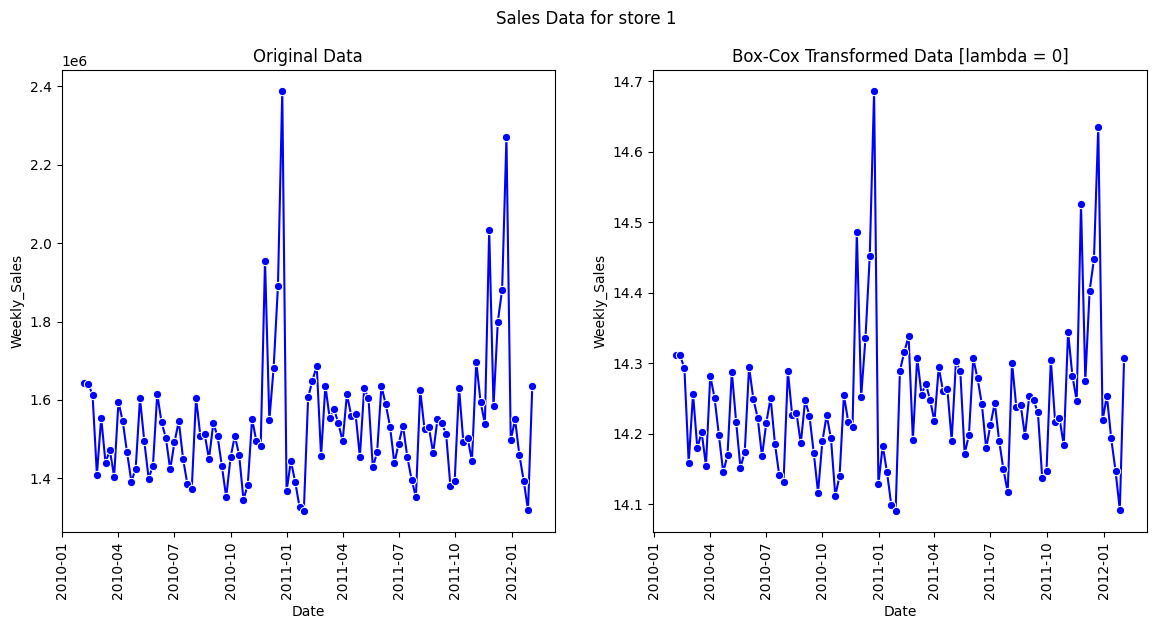

In [45]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data = df_train_1, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Original Data')

plt.subplot(1, 2, 2)
df_boxcox_1 = pd.DataFrame(df_boxcox_1)
sns.lineplot(data = df_boxcox_1, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Box-Cox Transformed Data [lambda = 0]')

plt.suptitle('Sales Data for store 1');

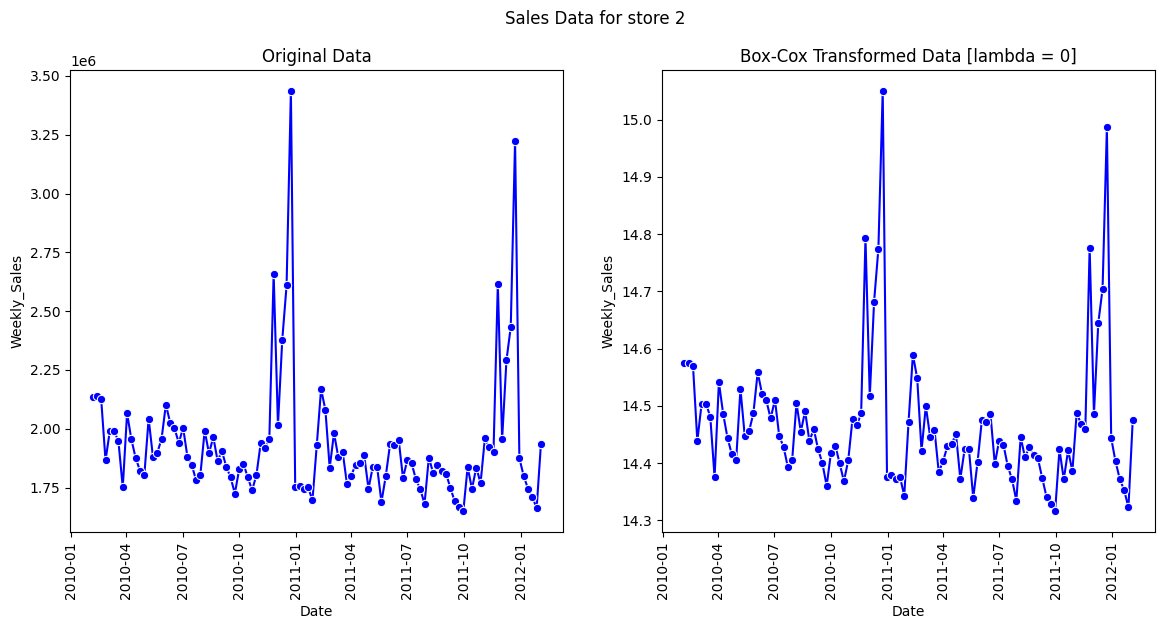

In [46]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data = df_train_2, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Original Data')

plt.subplot(1, 2, 2)
df_boxcox_2 = pd.DataFrame(df_boxcox_2)
sns.lineplot(data = df_boxcox_2, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Box-Cox Transformed Data [lambda = 0]')

plt.suptitle('Sales Data for store 2');

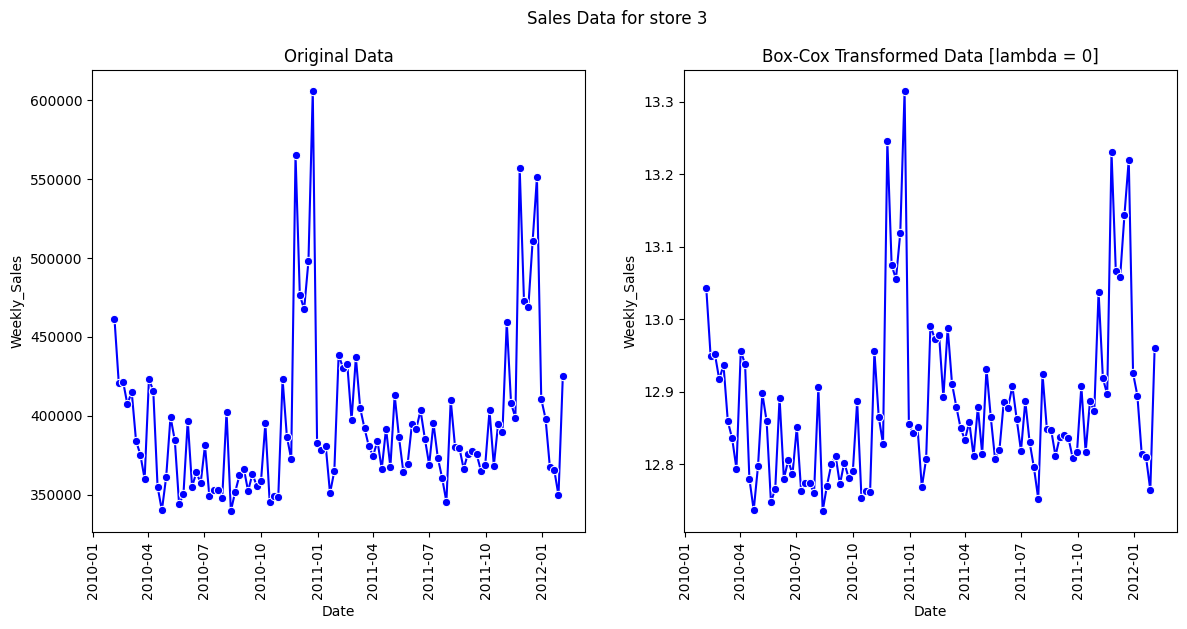

In [47]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data = df_train_3, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Original Data')

plt.subplot(1, 2, 2)
df_boxcox_3 = pd.DataFrame(df_boxcox_3)
sns.lineplot(data = df_boxcox_3, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Box-Cox Transformed Data [lambda = 0]')

plt.suptitle('Sales Data for store 3');

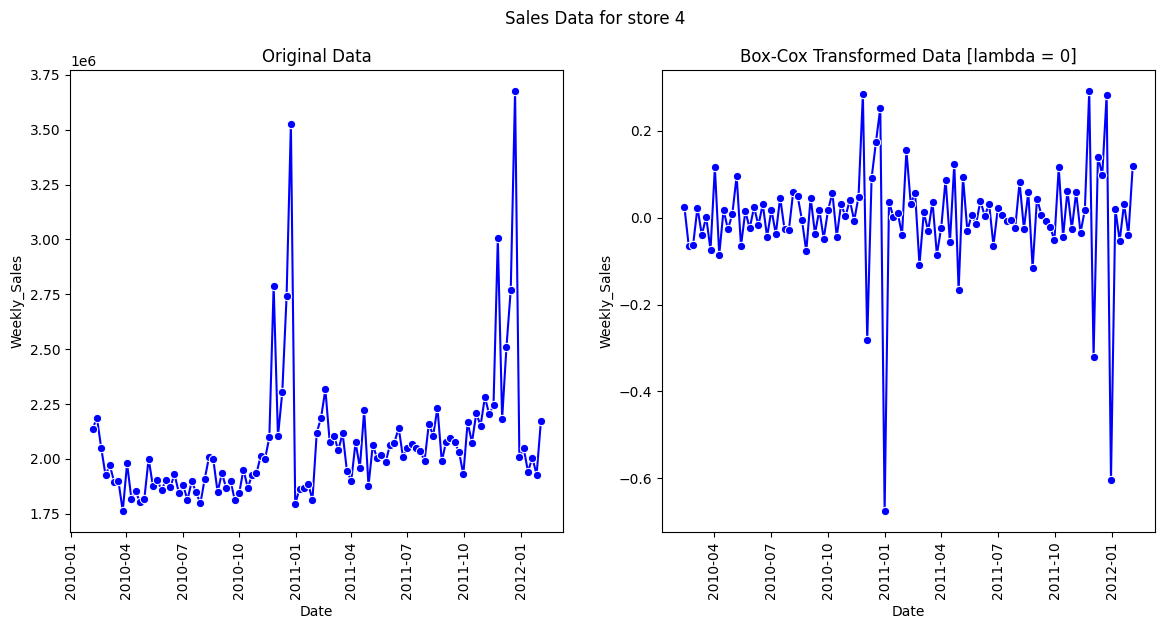

In [48]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data = df_train_4, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Original Data')

plt.subplot(1, 2, 2)
df_boxcox_4_diff = pd.DataFrame(df_boxcox_4_diff)
sns.lineplot(data = df_boxcox_4_diff, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Box-Cox Transformed Data [lambda = 0]')

plt.suptitle('Sales Data for store 4');

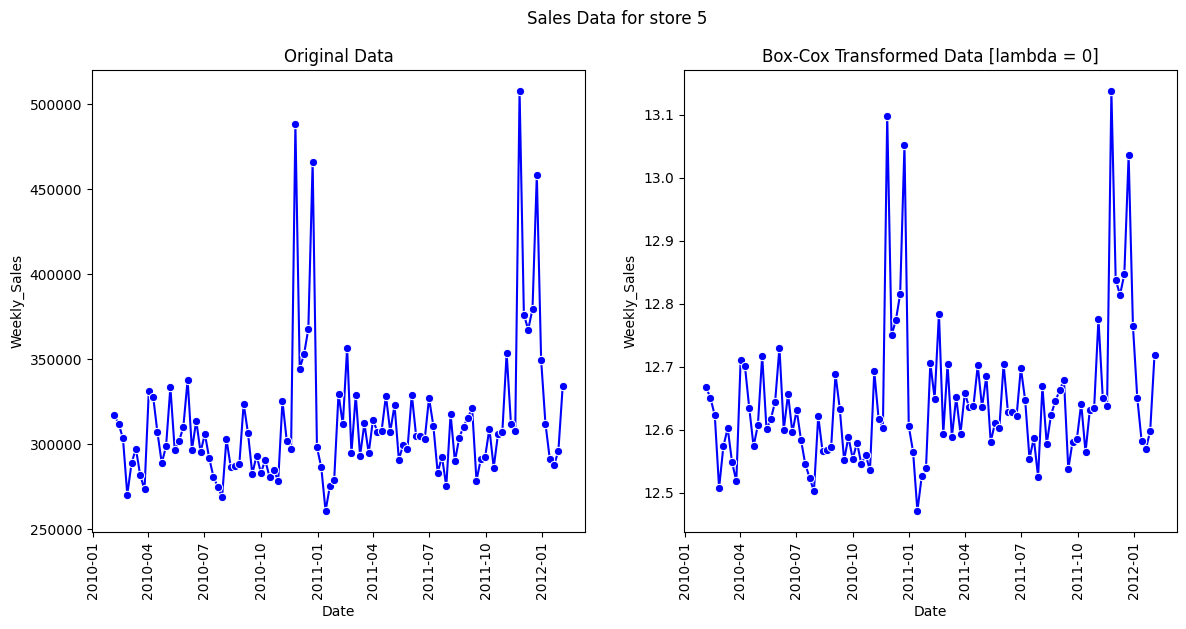

In [49]:
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data = df_train_5, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Original Data')

plt.subplot(1, 2, 2)
df_boxcox_5 = pd.DataFrame(df_boxcox_5)
sns.lineplot(data = df_boxcox_5, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Box-Cox Transformed Data [lambda = 0]')

plt.suptitle('Sales Data for store 5');

# ADFuller Test for all stores

Store 1

In [50]:
adfuller(df_boxcox_1)

(np.float64(-4.7346882628312),
 np.float64(7.2392985940601e-05),
 4,
 100,
 {'1%': np.float64(-3.497501033),
  '5%': np.float64(-2.89090644),
  '10%': np.float64(-2.5824349)},
 np.float64(-169.37267620332506))

P < 0.05, data is stationary for store 1

Store 2

In [51]:
adfuller(df_boxcox_2)

(np.float64(-3.261425192839886),
 np.float64(0.01669331981931809),
 7,
 97,
 {'1%': np.float64(-3.4996365338407074),
  '5%': np.float64(-2.8918307730370025),
  '10%': np.float64(-2.5829283377617176)},
 np.float64(-145.52141545061204))

p < 0.05, Data is stationary for store_2

Store 3

In [52]:
adfuller(df_boxcox_3)

(np.float64(-3.904008476399904),
 np.float64(0.002005544177260835),
 4,
 100,
 {'1%': np.float64(-3.497501033),
  '5%': np.float64(-2.89090644),
  '10%': np.float64(-2.5824349)},
 np.float64(-169.58453219280813))

p < 0.05, Data is stationary for Store 3

Store 4

In [53]:
adfuller(df_boxcox_4)

(np.float64(-1.6978605197525762),
 np.float64(0.432215137237584),
 8,
 96,
 {'1%': np.float64(-3.5003788874873405),
  '5%': np.float64(-2.8921519665075235),
  '10%': np.float64(-2.5830997960069446)},
 np.float64(-142.9268950321793))

Here since adfuller_test shows p>0.05 but because there is seasonality so we will use SARIMA model and it can perform differencing in itself as well and therefore, we don't need to consider differencing manually

# ADFuller test for store 5

In [54]:
adfuller(df_boxcox_5)

(np.float64(-4.194937825410941),
 np.float64(0.0006720221235234086),
 4,
 100,
 {'1%': np.float64(-3.497501033),
  '5%': np.float64(-2.89090644),
  '10%': np.float64(-2.5824349)},
 np.float64(-148.75963536944198))

we have p-value < 0.05, data is stationary for store_5

# Seasonal Decomposition for checking seasonality

For store 1

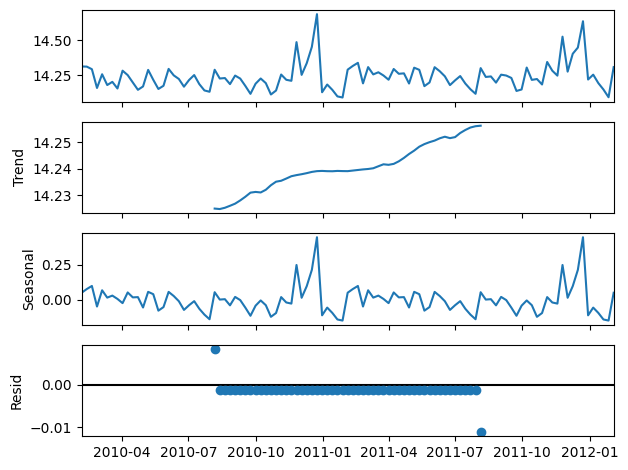

In [55]:
# we do Seasonal decomposition to check seasonality in data
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df_boxcox_1, model = 'additive')
decomposition.plot()
plt.show()

For STore 2

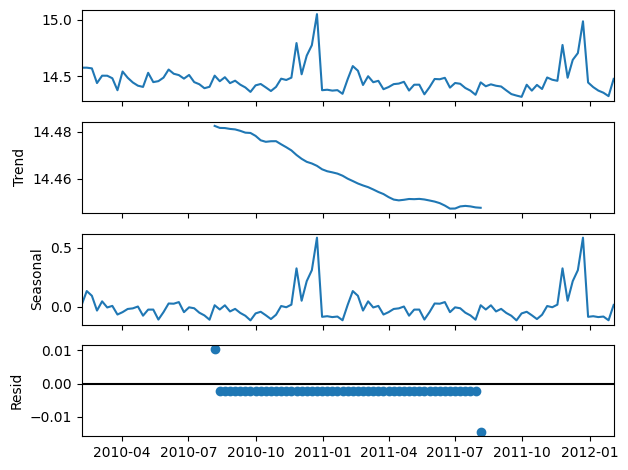

In [56]:
# we do Seasonal decomposition to check seasonality in data
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df_boxcox_2, model = 'additive')
decomposition.plot()
plt.show()

For store 3

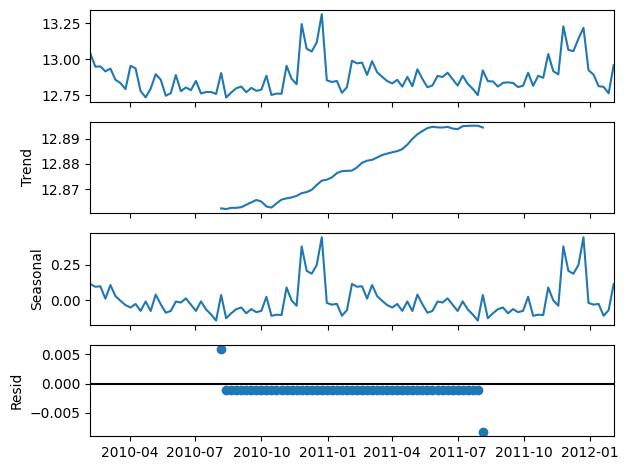

In [57]:
# we do Seasonal decomposition to check seasonality in data
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df_boxcox_3, model = 'additive')
decomposition.plot()
plt.show()

for Store 4

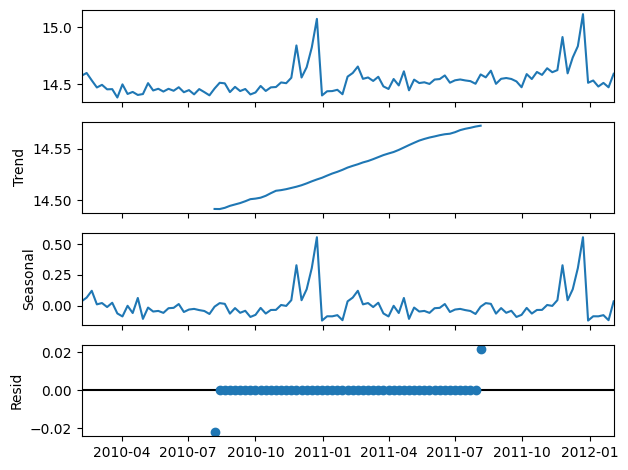

In [58]:
# we do Seasonal decomposition to check seasonality in data
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df_boxcox_4, model = 'additive')
decomposition.plot()
plt.show()

For Store 5

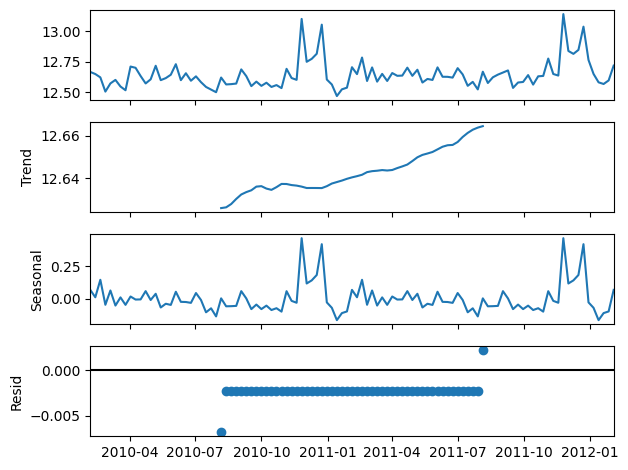

In [59]:
# we do Seasonal decomposition to check seasonality in data
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df_boxcox_5, model = 'additive')
decomposition.plot()
plt.show()

# Now, We need to check Auto Correlation Plots

Autocorrelation for Store 1

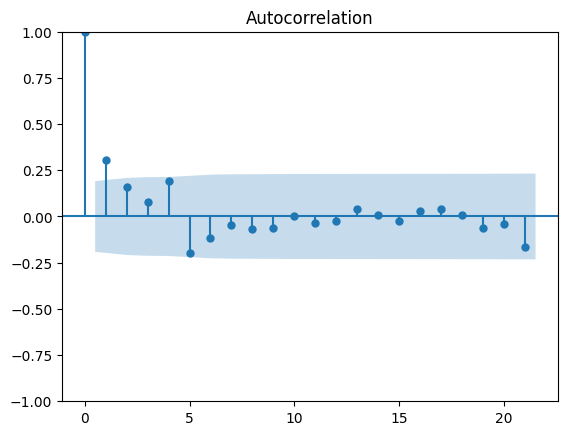

In [60]:
# this is for complete autocorrelation
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df_boxcox_1)
plt.show()

q = 1, near x = 1 for store 1

AutoCorrelation for Store 2

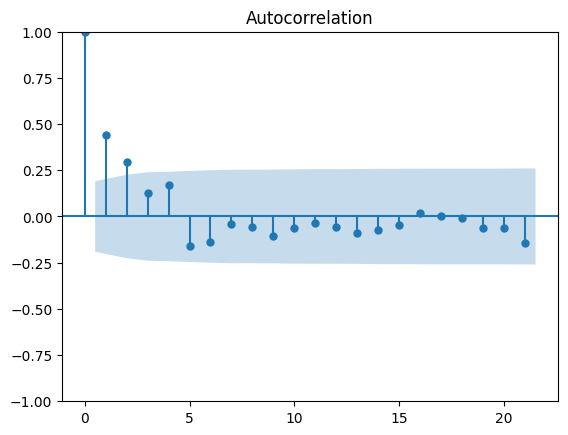

In [61]:
# this is for complete autocorrelation
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df_boxcox_2)
plt.show()

q = 2, because both lines at x = 1, x =2 are continuous crossing significant region

Autocorrelation Plot for Store 3

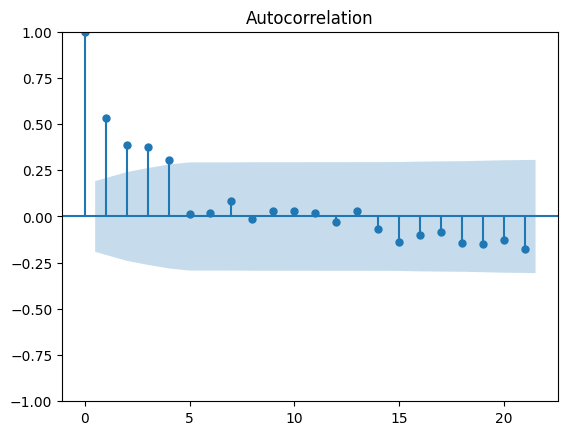

In [62]:
# this is for complete autocorrelation
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df_boxcox_3)
plt.show()

q = 3, but we will choose q = 2 because both other lines at x=2, and x = 3 are having equal correlation

Autocorrelation plot for Store 4

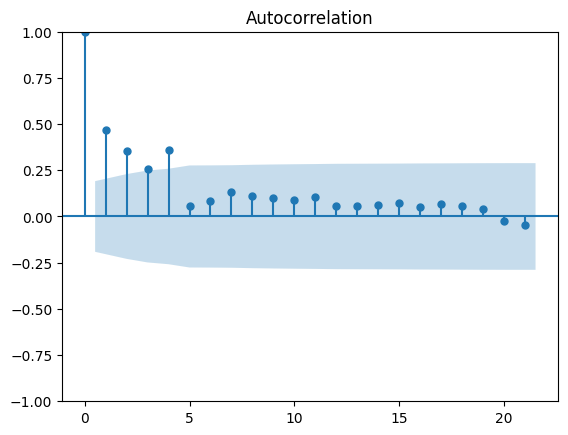

In [63]:
# this is for complete autocorrelation
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df_boxcox_4)
plt.show()

Autocorrelation Plot for Store 5

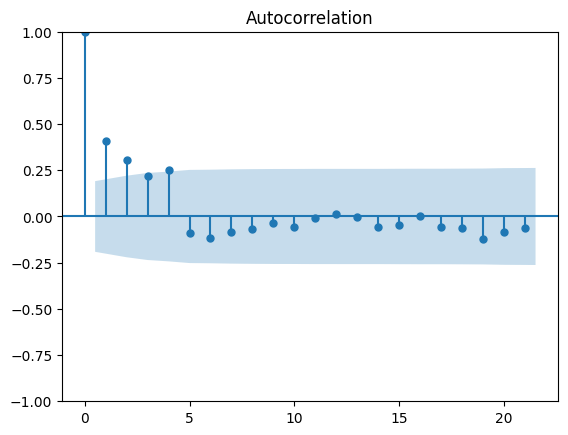

In [64]:
# this is for complete autocorrelation
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df_boxcox_5)
plt.show()

from above AutoCorrelation, we have two continuous lines crossing shaded region near point 1, so our q = 1, because line near 1 are approx max correlated related to other line

# Partial AutoCorrelation Plots

Partial AutoCorrelation Plot for STore 1

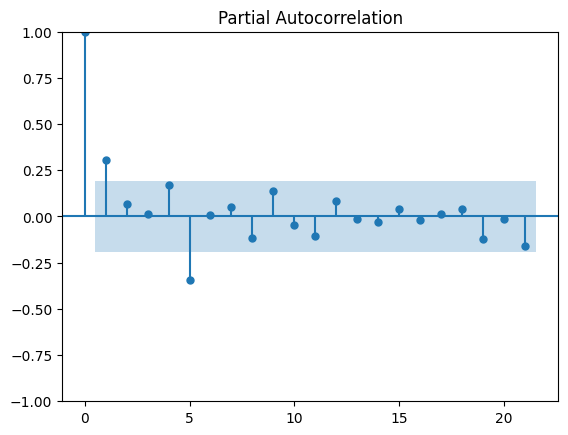

In [65]:
# Now we also check partial Autocorrelation
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df_boxcox_1)
plt.show()

we got p = 1 from line near point 5

For Store 2

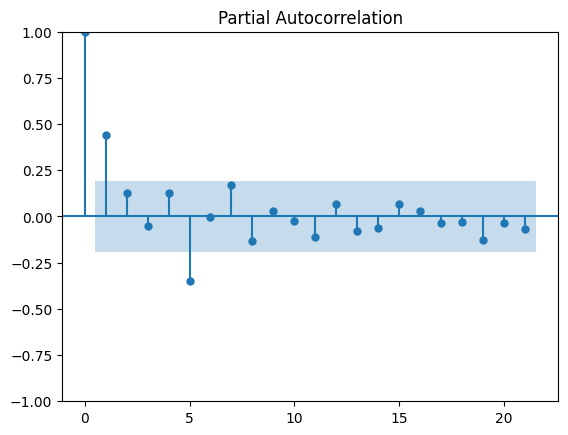

In [66]:
# Now we also check partial Autocorrelation
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df_boxcox_2)
plt.show()

p = 1 for store 2

Store 3

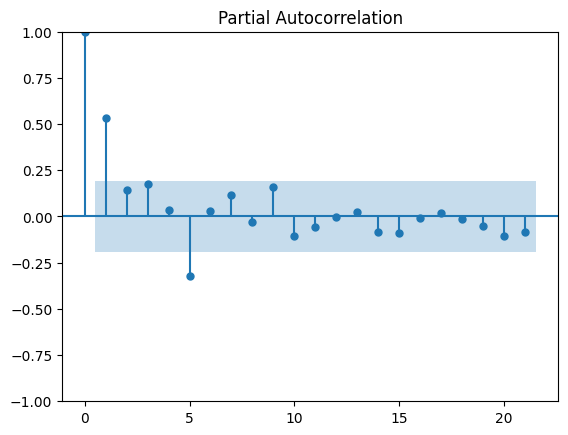

In [67]:
# Now we also check partial Autocorrelation
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df_boxcox_3)
plt.show()

p = 1 for store 3

Store 4

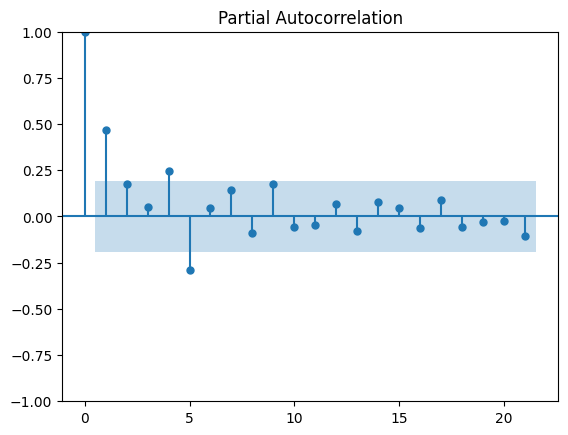

In [68]:
# Now we also check partial Autocorrelation
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df_boxcox_4)
plt.show()

p = 1 for STore 4

Store 5

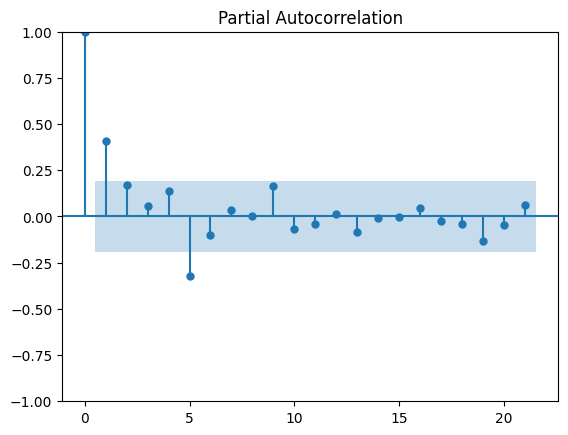

In [69]:
# Now we also check partial Autocorrelation
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df_boxcox_5)
plt.show()

p = 1 for store 5

# Applying Time Series forcasting model SARIMA, Because there is seasonality in data for each store and this model can handle seasonality factor

Store 1

In [70]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_1 = SARIMAX(df_boxcox_1, order = (1, 0, 1), seasonal_order = (1, 0, 1, 52))
sarima_model_1 = sarima_1.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


Store 2

In [71]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_2 = SARIMAX(df_boxcox_2, order = (1, 0, 2), seasonal_order = (1, 0, 2, 52))
sarima_model_2 = sarima_2.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Store 3

In [72]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_3 = SARIMAX(df_boxcox_3, order = (1, 0, 2), seasonal_order = (1, 0, 2, 52))
sarima_model_3 = sarima_3.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Store 4

In [73]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_4 = SARIMAX(df_boxcox_4, order = (1, 0, 2), seasonal_order = (1, 0, 2, 52))
sarima_model_4 = sarima_4.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Store 5

In [74]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_5 = SARIMAX(df_boxcox_5, order = (1, 0, 2), seasonal_order = (1, 0, 2, 52))
sarima_model_5 = sarima_5.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# Prediction for Store 1 to 5

Store 1

In [75]:
train_len = 105
sarima_model_pred_1 = sarima_model_1.predict(start = train_len, end = len(df_1) - 1)

Store 2

In [76]:
train_len = 105
sarima_model_pred_2 = sarima_model_2.predict(start = train_len, end = len(df_2) - 1)

Store 3

In [77]:
train_len = 105
sarima_model_pred_3 = sarima_model_3.predict(start = train_len, end = len(df_3) - 1)

Store 4

In [78]:
train_len = 105
sarima_model_pred_4 = sarima_model_4.predict(start = train_len, end = len(df_4) - 1)

Store 5

In [79]:
train_len = 105
sarima_model_pred_5 = sarima_model_5.predict(start = train_len, end = len(df_5) - 1)

# appending training and forcasted data

Store 1

In [80]:
df_boxcox_pred_1 = pd.concat([df_boxcox_1, sarima_model_pred_1])
df_boxcox_pred_1

,Weekly_Sales,predicted_mean
2010-02-05,14.312455,NaN
2010-02-12,14.311400,NaN
2010-02-19,14.292966,NaN
2010-02-26,14.158907,NaN
2010-03-05,14.256862,NaN
...,...,...
2012-09-28,NaN,14.161368
2012-10-05,NaN,14.358325
2012-10-12,NaN,14.253214
2012-10-19,NaN,14.299988


Store 2

In [81]:
df_boxcox_pred_2 = pd.concat([df_boxcox_2, sarima_model_pred_2])
df_boxcox_pred_2

,Weekly_Sales,predicted_mean
2010-02-05,14.574909,NaN
2010-02-12,14.575292,NaN
2010-02-19,14.569024,NaN
2010-02-26,14.438824,NaN
2010-03-05,14.504154,NaN
...,...,...
2012-09-28,NaN,14.311065
2012-10-05,NaN,14.417729
2012-10-12,NaN,14.367586
2012-10-19,NaN,14.420772


Store 3

In [82]:
df_boxcox_pred_3 = pd.concat([df_boxcox_3, sarima_model_pred_3])
df_boxcox_pred_3

,Weekly_Sales,predicted_mean
2010-02-05,13.042502,NaN
2010-02-12,12.949744,NaN
2010-02-19,12.951912,NaN
2010-02-26,12.917072,NaN
2010-03-05,12.936521,NaN
...,...,...
2012-09-28,NaN,12.831095
2012-10-05,NaN,12.906329
2012-10-12,NaN,12.833733
2012-10-19,NaN,12.897457


Store 4

In [83]:
df_boxcox_pred_4 = pd.concat([df_boxcox_4, sarima_model_pred_4])
df_boxcox_pred_4

,Weekly_Sales,predicted_mean
2010-02-05,14.574045,NaN
2010-02-12,14.598639,NaN
2010-02-19,14.533282,NaN
2010-02-26,14.470815,NaN
2010-03-05,14.494081,NaN
...,...,...
2012-09-28,NaN,14.518583
2012-10-05,NaN,14.663672
2012-10-12,NaN,14.622628
2012-10-19,NaN,14.699608


Store 5

In [84]:
df_boxcox_pred_5 = pd.concat([df_boxcox_5, sarima_model_pred_5])
df_boxcox_pred_5

,Weekly_Sales,predicted_mean
2010-02-05,12.667203,NaN
2010-02-12,12.650200,NaN
2010-02-19,12.622964,NaN
2010-02-26,12.507220,NaN
2010-03-05,12.573683,NaN
...,...,...
2012-09-28,NaN,12.620328
2012-10-05,NaN,12.672038
2012-10-12,NaN,12.599220
2012-10-19,NaN,12.662527


# Reverse Tranformation values from boxcox to Original Data Values

Store 1

In [85]:
df_pred_1 = np.exp(df_boxcox_pred_1)
df_pred_1

,Weekly_Sales,predicted_mean
2010-02-05,1643690.90,NaN
2010-02-12,1641957.44,NaN
2010-02-19,1611968.17,NaN
2010-02-26,1409727.59,NaN
2010-03-05,1554806.68,NaN
...,...,...
2012-09-28,NaN,1.413201e+06
2012-10-05,NaN,1.720843e+06
2012-10-12,NaN,1.549146e+06
2012-10-19,NaN,1.623326e+06


Store 2

In [86]:
df_pred_2 = np.exp(df_boxcox_pred_2)
df_pred_2

,Weekly_Sales,predicted_mean
2010-02-05,2136989.46,NaN
2010-02-12,2137809.50,NaN
2010-02-19,2124451.54,NaN
2010-02-26,1865097.27,NaN
2010-03-05,1991013.13,NaN
...,...,...
2012-09-28,NaN,1.641408e+06
2012-10-05,NaN,1.826165e+06
2012-10-12,NaN,1.736855e+06
2012-10-19,NaN,1.831731e+06


Store 3

In [87]:
df_pred_3 = np.exp(df_boxcox_pred_3)
df_pred_3

,Weekly_Sales,predicted_mean
2010-02-05,461622.22,NaN
2010-02-12,420728.96,NaN
2010-02-19,421642.19,NaN
2010-02-26,407204.86,NaN
2010-03-05,415202.04,NaN
...,...,...
2012-09-28,NaN,373657.559212
2012-10-05,NaN,402853.855137
2012-10-12,NaN,374644.718950
2012-10-19,NaN,399295.495612


Store 4

In [88]:
df_pred_4 = np.exp(df_boxcox_pred_4)
df_pred_4

,Weekly_Sales,predicted_mean
2010-02-05,2135143.87,NaN
2010-02-12,2188307.39,NaN
2010-02-19,2049860.26,NaN
2010-02-26,1925728.84,NaN
2010-03-05,1971057.44,NaN
...,...,...
2012-09-28,NaN,2.019949e+06
2012-10-05,NaN,2.335348e+06
2012-10-12,NaN,2.241438e+06
2012-10-19,NaN,2.420797e+06


Store 5

In [89]:
df_pred_5 = np.exp(df_boxcox_pred_5)
df_pred_5

,Weekly_Sales,predicted_mean
2010-02-05,317173.10,NaN
2010-02-12,311825.70,NaN
2010-02-19,303447.57,NaN
2010-02-26,270281.63,NaN
2010-03-05,288855.71,NaN
...,...,...
2012-09-28,NaN,302648.718934
2012-10-05,NaN,318710.407614
2012-10-12,NaN,296327.473745
2012-10-19,NaN,315693.377192


# Ploting Predictions Vs Original Testing Data for STore 1 To 5

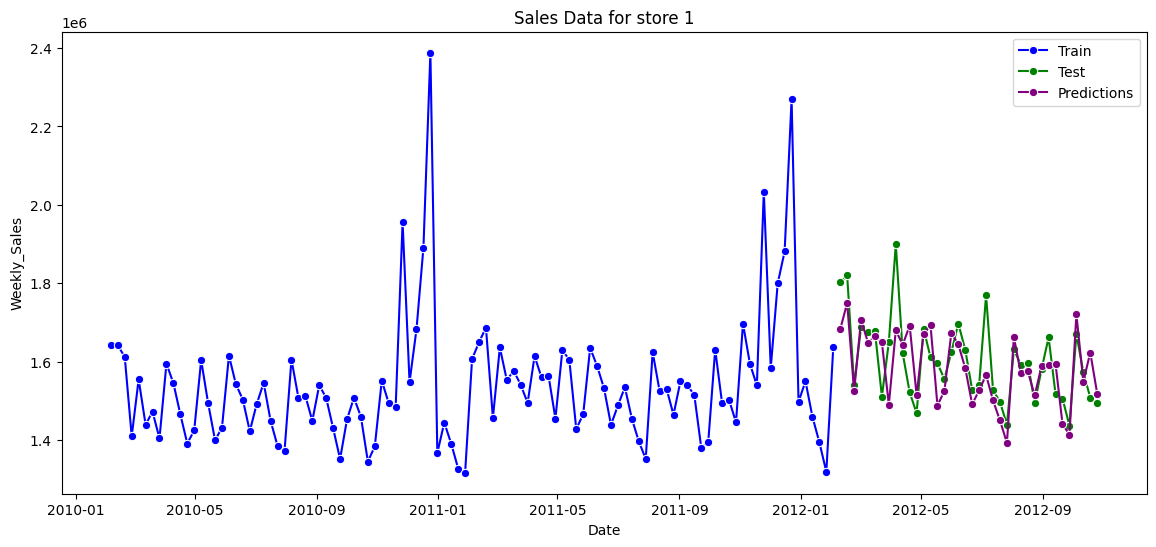

In [90]:
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train_1, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test_1, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = df_pred_1.index[train_len:], y = df_pred_1['predicted_mean'].iloc[105:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Sales Data for store 1');

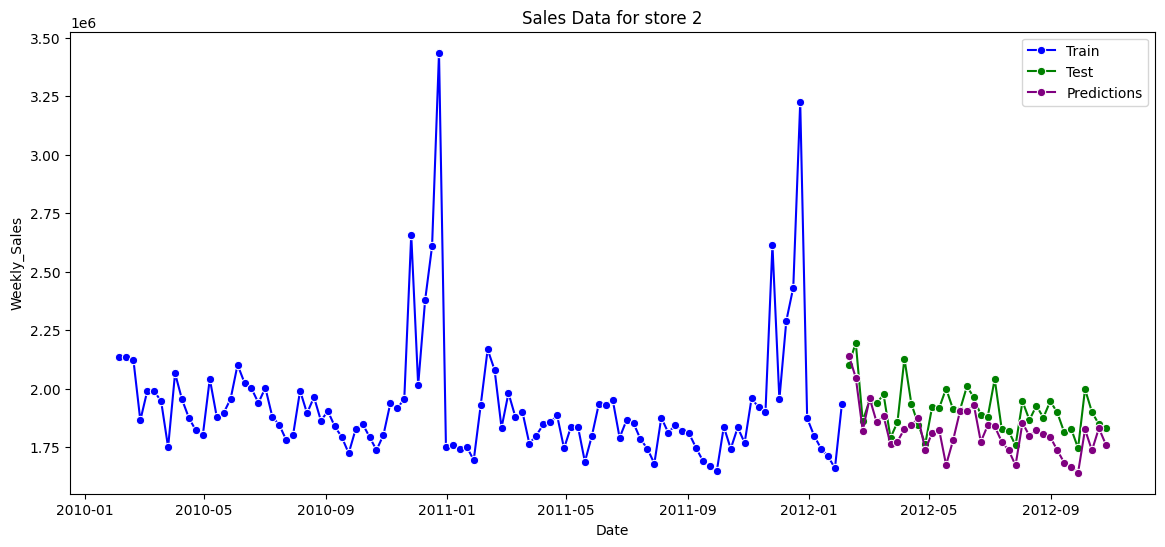

In [91]:
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train_2, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test_2, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = df_pred_2.index[train_len:], y = df_pred_2['predicted_mean'].iloc[105:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Sales Data for store 2');

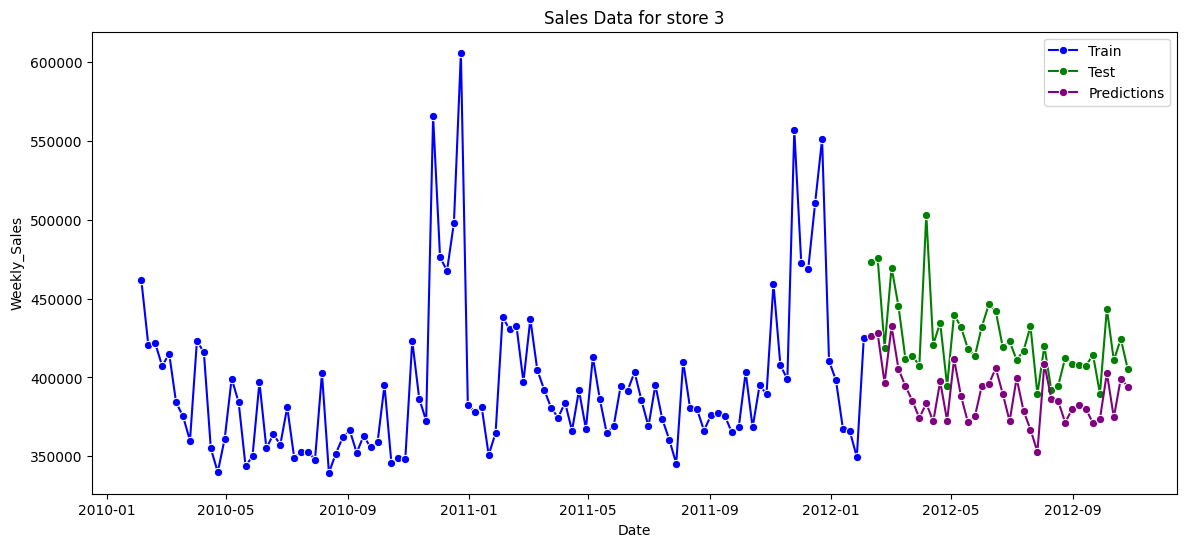

In [92]:
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train_3, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test_3, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = df_pred_3.index[train_len:], y = df_pred_3['predicted_mean'].iloc[105:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Sales Data for store 3');

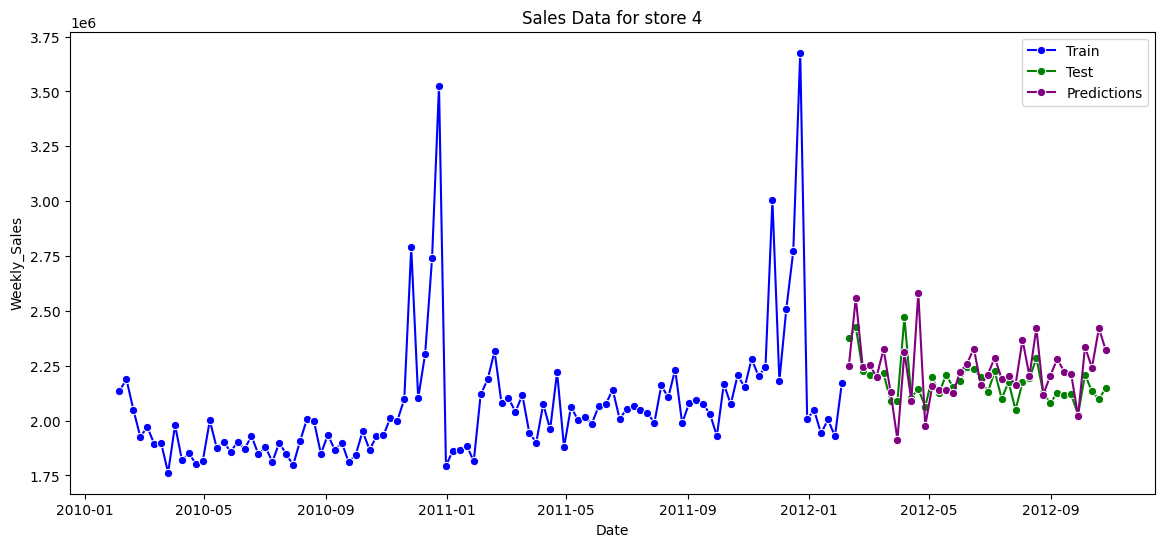

In [93]:
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train_4, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test_4, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = df_pred_4.index[train_len:], y = df_pred_4['predicted_mean'].iloc[105:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Sales Data for store 4');

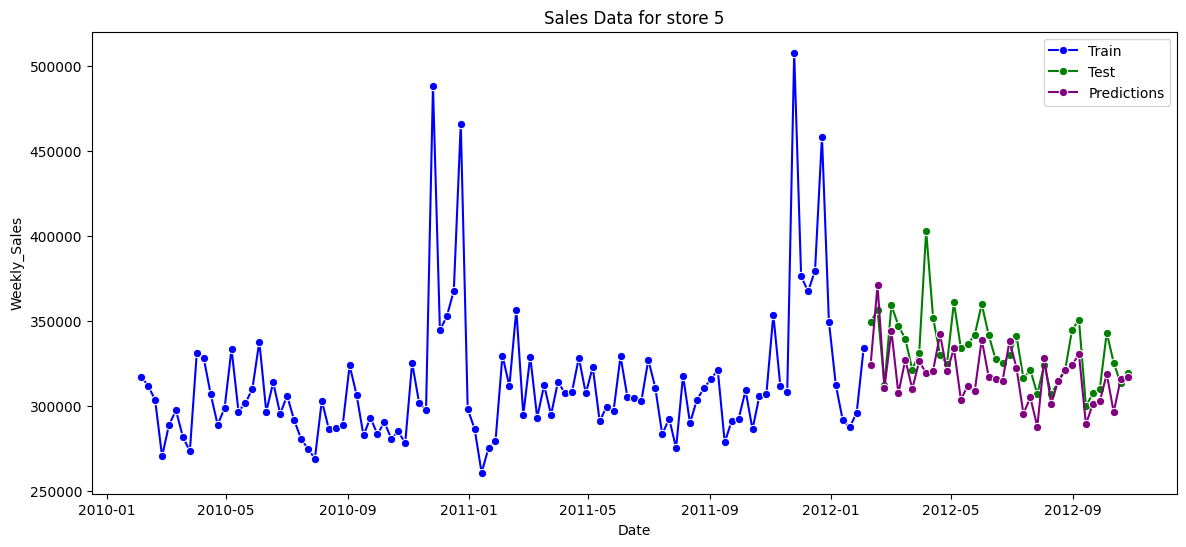

In [94]:
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train_5, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test_5, x = 'Date', y = 'Weekly_Sales', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = df_pred_5.index[train_len:], y = df_pred_5['predicted_mean'].iloc[105:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Sales Data for store 5');

Model for Stores 1,2,4,5 are performing good but Model 3 Is not performing good

# Following are performance metrics for each of Store 1 to 5 , RMSE Scores


In [95]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_true = df_test_1['Weekly_Sales'], y_pred= df_pred_1['predicted_mean'].iloc[train_len:]))

rmse = np.round(rmse, 2)
performance_df_temp = pd.DataFrame(index = [0], data = {'Model': 'SARIMA', 'RMSE': rmse})

performance_df_temp.set_index('Model', inplace = True)
performance_df_temp

,RMSE
Model,
SARIMA,81904.07


In [96]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_true = df_test_2['Weekly_Sales'], y_pred= df_pred_2['predicted_mean'].iloc[train_len:]))

rmse = np.round(rmse, 2)
performance_df_temp = pd.DataFrame(index = [0], data = {'Model': 'SARIMA', 'RMSE': rmse})

performance_df_temp.set_index('Model', inplace = True)
performance_df_temp

,RMSE
Model,
SARIMA,122675.37


In [97]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_true = df_test_3['Weekly_Sales'], y_pred= df_pred_3['predicted_mean'].iloc[train_len:]))

rmse = np.round(rmse, 2)
performance_df_temp = pd.DataFrame(index = [0], data = {'Model': 'SARIMA', 'RMSE': rmse})

performance_df_temp.set_index('Model', inplace = True)
performance_df_temp

,RMSE
Model,
SARIMA,40089.5


In [98]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_true = df_test_4['Weekly_Sales'], y_pred= df_pred_4['predicted_mean'].iloc[train_len:]))

rmse = np.round(rmse, 2)
performance_df_temp = pd.DataFrame(index = [0], data = {'Model': 'SARIMA', 'RMSE': rmse})

performance_df_temp.set_index('Model', inplace = True)
performance_df_temp

,RMSE
Model,
SARIMA,129232.06


In [99]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_true = df_test_5['Weekly_Sales'], y_pred= df_pred_5['predicted_mean'].iloc[train_len:]))

rmse = np.round(rmse, 2)
performance_df_temp = pd.DataFrame(index = [0], data = {'Model': 'SARIMA', 'RMSE': rmse})

performance_df_temp.set_index('Model', inplace = True)
performance_df_temp

,RMSE
Model,
SARIMA,22790.47
